# EN3160 Image Processing & Computer Vision - Assignment 01
**Name:** Meedeniya M.M.H

**Index Number:** 230407K

**GitHub Repository:** https://github.com/manjarimeedeniya/EN3160-Assignment-01

In [2]:
# Importing required libraries
import cv2 as cv
import numpy as np 
import matplotlib.pyplot as plt

## Question 1

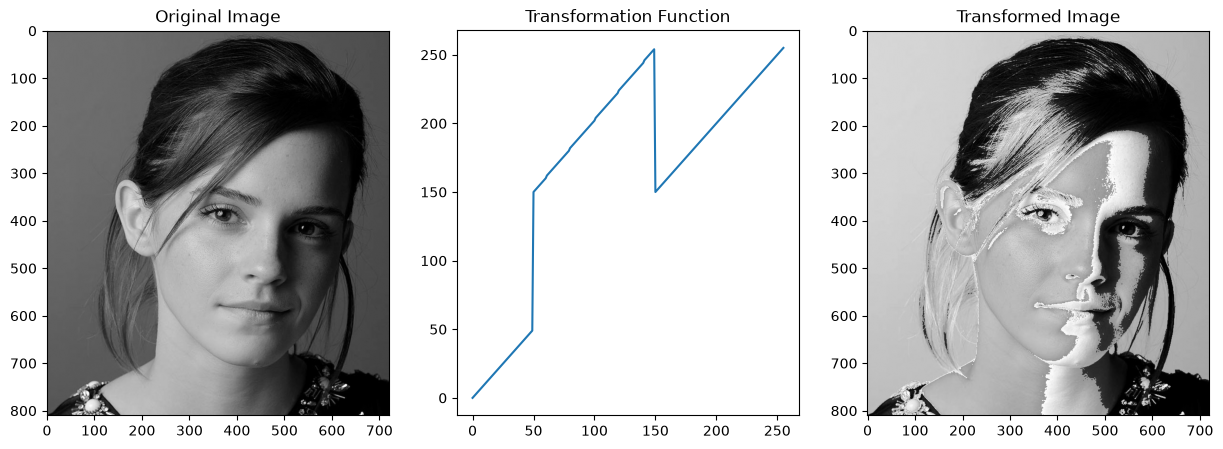

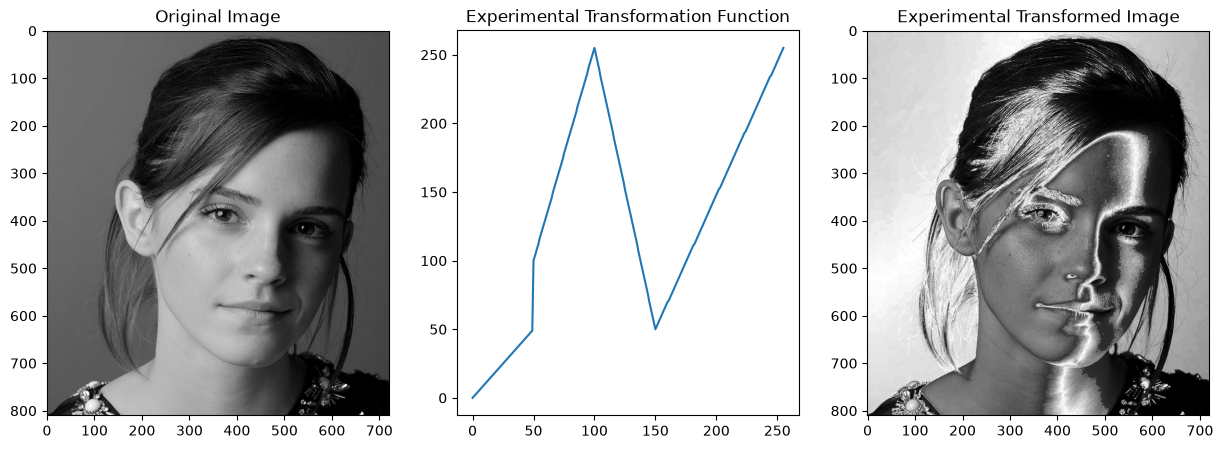

In [54]:
def intensity_transform(im,breakpoints):
    # Create an empty lookup table for intensities 0-255
    transform = np.zeros(256, dtype=np.uint8)

    # Generate each piecewise-linear segment
    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]
        if x2 == x1:
            continue

        # Input intensity values in this segment
        x = np.arange(x1, x2 + 1)

        # Linear interpolation
        y = y1 + (y2 - y1) * (x - x1) / (x2 - x1)

        transform[x] = np.round(y).astype(np.uint8)

    # Apply transformation using LUT
    transformed_image = cv.LUT(im, transform)

    return transformed_image, transform    



image1 = cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question1.jpeg',cv.IMREAD_GRAYSCALE)  # Read the first image in grayscale

bps = np.array([[0,0],[50,50],[50,150],[150,255],[150,150],[255,255]])  # Define breakpoints 
bps1 = np.array([[0,0],[50,50],[50,100],[100,255],[150,50],[255,255]])

image_transformed,transform=intensity_transform(image1, bps)
image_with_experimental_transform,transform1=intensity_transform(image1, bps1)

# Display the original and transformed images
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(image1,cmap='gray')
axes[0].set_title('Original Image')
axes[2].imshow(image_transformed,cmap='gray')
axes[2].set_title('Transformed Image') 
axes[1].plot(transform)
axes[1].set_title('Transformation Function')    
plt.show()  # Show the plots

fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(image1,cmap='gray')
axes[0].set_title('Original Image')
axes[2].imshow(image_with_experimental_transform,cmap='gray')
axes[2].set_title('Experimental Transformed Image') 
axes[1].plot(transform1)
axes[1].set_title('Experimental Transformation Function')    
plt.show()  # Show the plots

## Question 2

Detected Peaks -> Gray Matter: 149, White Matter: 169


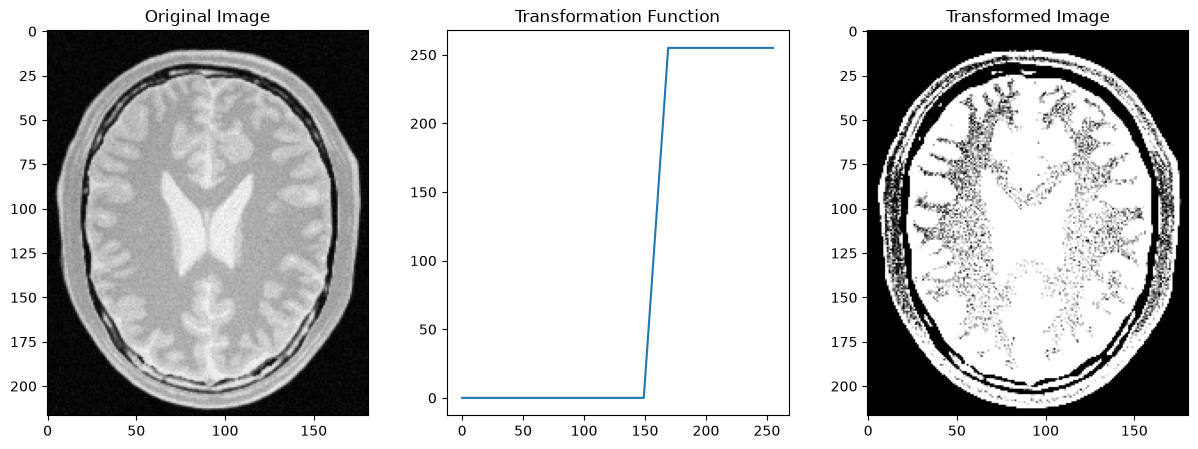

In [57]:
# 1. Load image
mri_image = cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question2.jpeg', cv.IMREAD_GRAYSCALE)

# 2. Calculate histogram (ignoring pure black background < 10)
hist = cv.calcHist([mri_image], [0], None, [256], [0, 256]).flatten()
hist[:10] = 0  # Ignore background zeros

# 3. Smooth histogram using a simple moving average to clear noise
kernel = np.ones(15) / 15
smoothed_hist = np.convolve(hist, kernel, mode='same')

# 4. Find tissue ranges by splitting histogram into mid and high intensity regions
# Gray matter peak is in the middle (e.g., 50 to 150)
gm_peak = np.argmax(smoothed_hist[50:150]) + 50

# White matter peak is in the higher region (e.g., 150 to 240)
wm_peak = np.argmax(smoothed_hist[150:240]) + 150

print(f"Detected Peaks -> Gray Matter: {gm_peak}, White Matter: {wm_peak}")

# 5. Build dynamic breakpoints automatically
# (a) White Matter Accentuation: Ramps up around white matter peak
bps_wm_auto = np.array([
    [0, 0],
    [gm_peak, 0],
    [wm_peak, 255],
    [255, 255]
])

# (b) Gray Matter Accentuation: Peak shape around gray matter intensity
bps_gm_auto = np.array([
    [0, 0],
    [gm_peak - 30, 0],
    [gm_peak, 255],
    [wm_peak, 0],
    [255, 0]
])

# Apply transformations using your existing function
img_wm, transform_wm = intensity_transform(mri_image, bps_wm_auto)
img_gm, transform_gm = intensity_transform(mri_image, bps_gm_auto)

# Display the original and transformed images
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(mri_image,cmap='gray')
axes[0].set_title('Original Image')
axes[2].imshow(img_wm,cmap='gray')
axes[2].set_title('Transformed Image') 
axes[1].plot(transform_wm)
axes[1].set_title('Transformation Function')    
plt.show()  # Show the plots

## Question 3

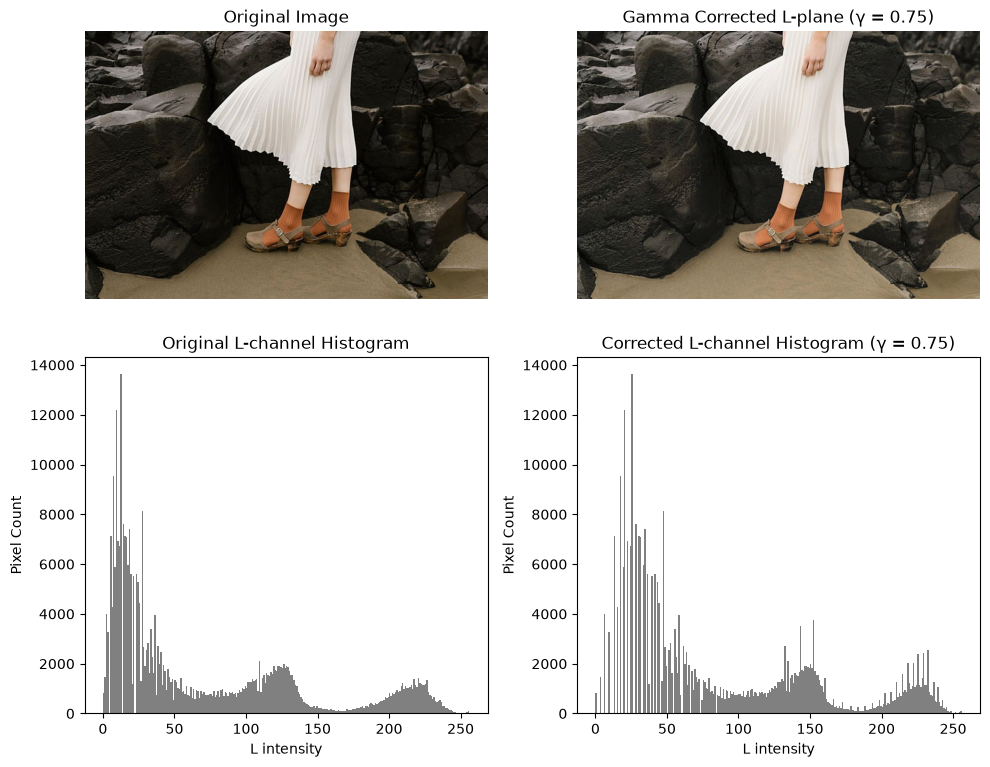

In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read Image
img_bgr = cv2.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question3.jpeg')  # Replace with your image file path
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 2. Convert to LAB color space
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

# 3. Apply Gamma Correction to L-plane
gamma = 0.75  # Adjust gamma: < 1.0 brightens, > 1.0 darkens
L_normalized = L / 255.0
L_corrected = np.uint8(np.clip(np.power(L_normalized, gamma) * 255, 0, 255))

# 4. Merge back and convert to RGB
lab_corrected = cv2.merge([L_corrected, a, b])
rgb_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2RGB)

# 5. Display Images and Histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Images
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(rgb_corrected)
axes[0, 1].set_title(f"Gamma Corrected L-plane (γ = {gamma})")
axes[0, 1].axis('off')

# Histograms of L-plane
axes[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color='gray')
axes[1, 0].set_title("Original L-channel Histogram")
axes[1, 0].set_xlabel("L intensity")
axes[1, 0].set_ylabel("Pixel Count")

axes[1, 1].hist(L_corrected.ravel(), bins=256, range=[0, 256], color='gray')
axes[1, 1].set_title(f"Corrected L-channel Histogram (γ = {gamma})")
axes[1, 1].set_xlabel("L intensity")
axes[1, 1].set_ylabel("Pixel Count")

plt.tight_layout()
plt.show()

## Question 4


### (a)

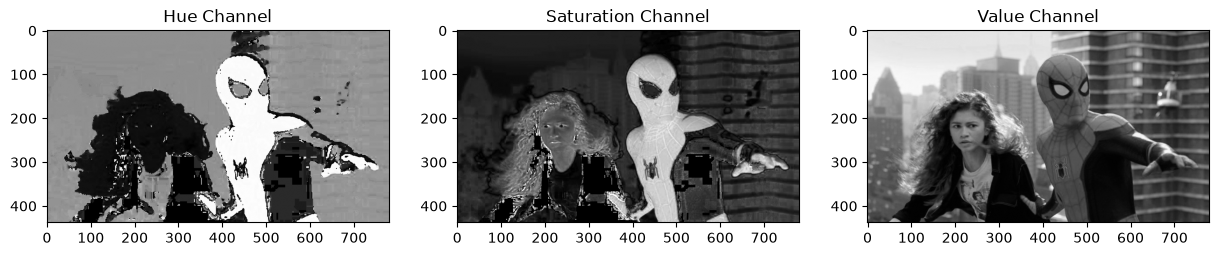

In [ ]:
image4=cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question4.jpeg')  # Read the image 
hsv=cv.cvtColor(image4,cv.COLOR_BGR2HSV)  # Convert to HSV color space
H,S,V=cv.split(hsv)  # Split into H, S, V channels

fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(H,cmap='gray')
axes[0].set_title('Hue Channel')
axes[2].imshow(V,cmap='gray')
axes[2].set_title('Value Channel') 
axes[1].imshow(S,cmap='gray')
axes[1].set_title('Saturation Channel')    
plt.show()  # Show the plots

### (b)

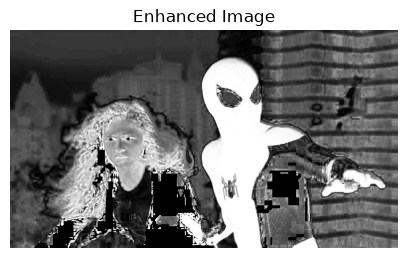

In [26]:
sigma=70
a=0.5
def transform_saturation(a):
    S_float = S.astype(np.float32)  # Convert to float for processing
    S_new = S_float + a*128*np.exp(-((S_float-128)**2)/(2*sigma**2))  # Apply Gaussian function
    S_new = np.minimum(S_new,255).astype(np.uint8)  # Ensure values are in [0, 255] and convert back to uint8
    hsv_new=cv.merge([H,S_new,V])  # Merge modified S channel back with H and V
    result=cv.cvtColor(hsv_new,cv.COLOR_HSV2BGR)  # Convert back to BGR color space
    result1=cv.cvtColor(result,cv.COLOR_BGR2RGB)
    return S_new

enhanced_image1 = transform_saturation(0.75)
plt.figure(figsize=(5,4))
plt.imshow(enhanced_image1,cmap='gray')
plt.title('Enhanced Image')
plt.axis('off')
plt.show()

### (c)

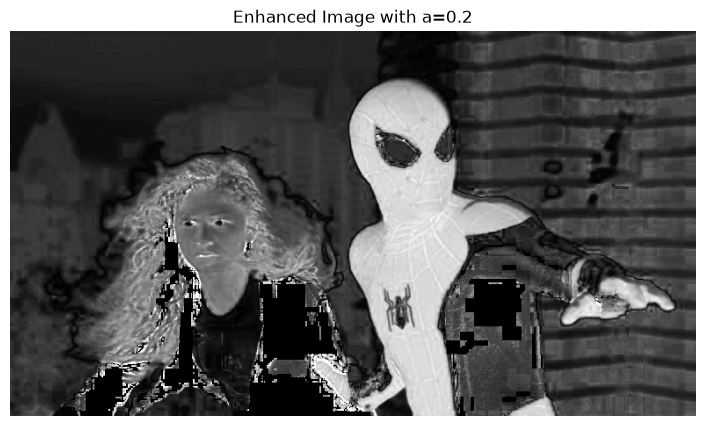

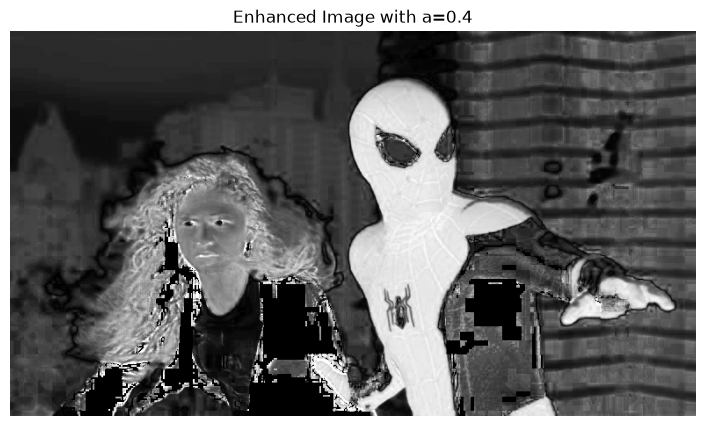

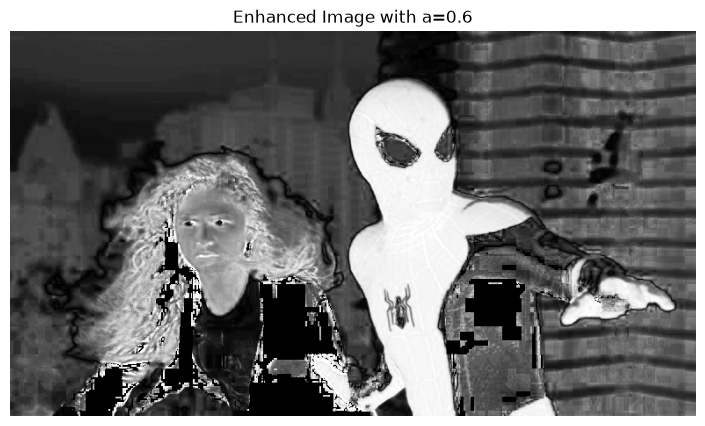

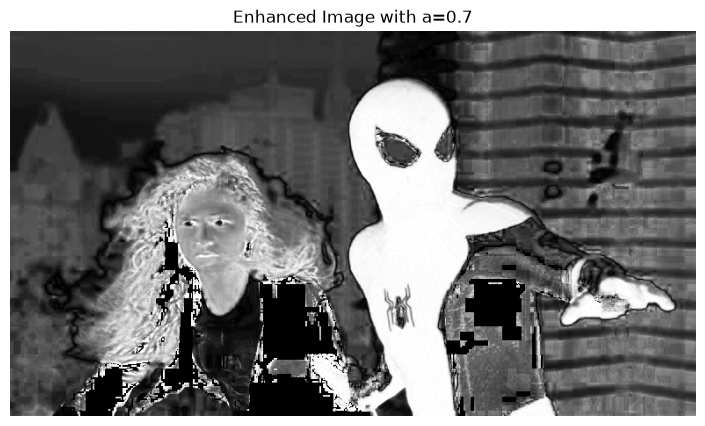

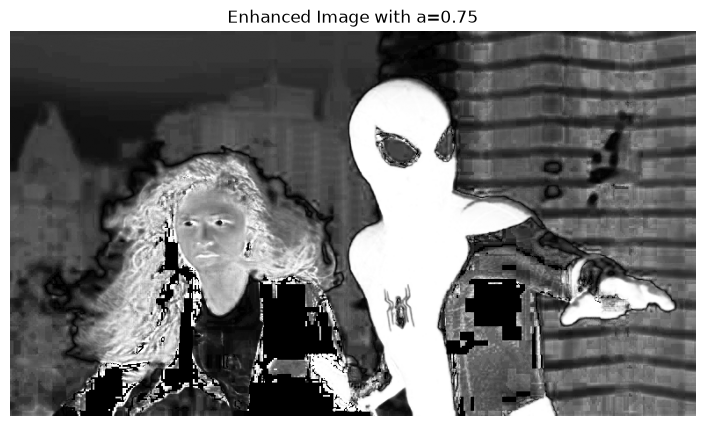

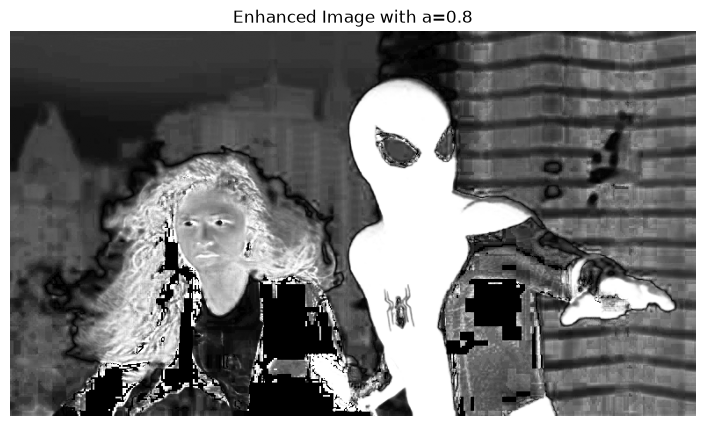

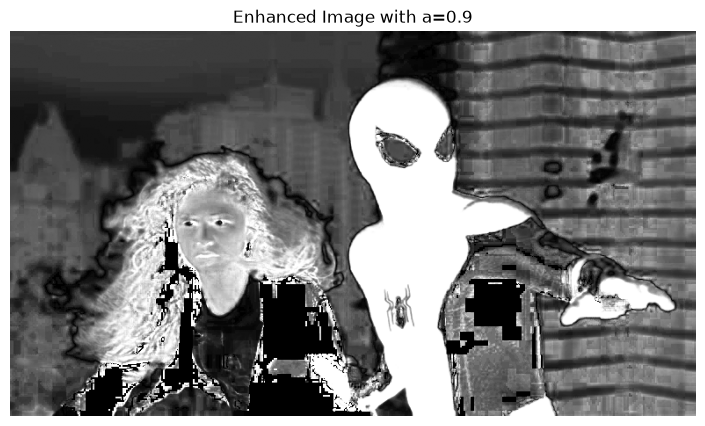

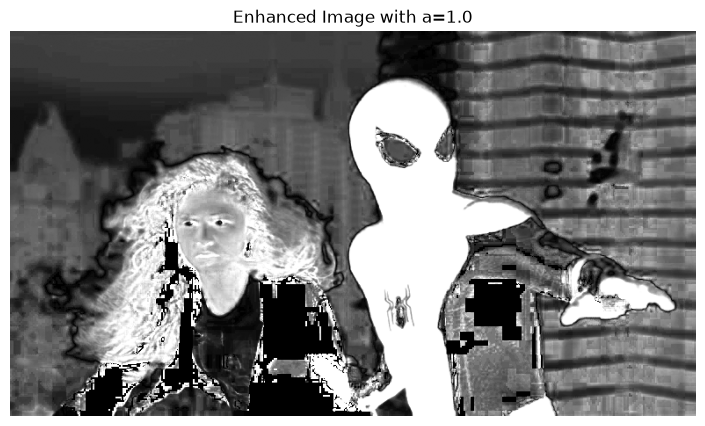

In [27]:
for a in [0.2,0.4,0.6,0.7,0.75,0.8,0.9,1.0]:
    resulting_image=transform_saturation(a)
    plt.figure(figsize=(10,5))
    plt.imshow(resulting_image,cmap='gray')
    plt.title(f'Enhanced Image with a={a}')
    plt.axis('off')
    plt.show()

### (d)


In [ ]:
#for the chosen value a=0.7, the image shows a significant enhancement in saturation, making the colors appear more vivid and vibrant. The Gaussian function applied to the saturation channel effectively boosts the mid-range saturation values while preventing oversaturation of already high saturation areas. This results in a more visually appealing image with improved color contrast and depth.
a=0.7
S_new = transform_saturation(a)  # Apply the transformation with a=0.75
hsv_new=cv.merge([H,S_new,V])  # Merge modified S channel back with H and V
result=cv.cvtColor(hsv_new,cv.COLOR_HSV2BGR)  # Convert back to BGR color space
enhanced_image=cv.cvtColor(result,cv.COLOR_BGR2RGB)

C:\Users\USER\AppData\Local\Temp\ipykernel_23116\2726827665.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


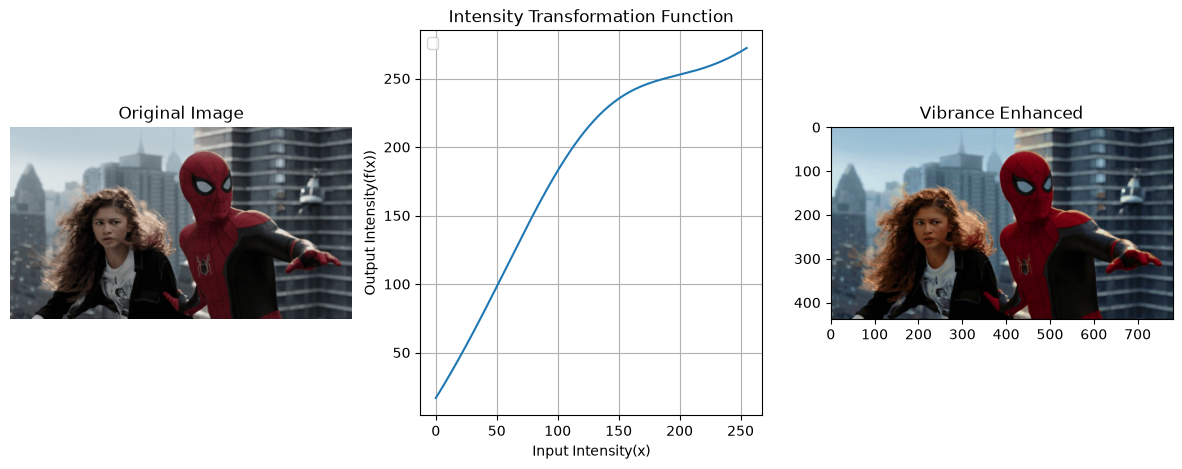

In [58]:
original_image=cv.cvtColor(image4,cv.COLOR_BGR2RGB)
x=np.arange(256,dtype=np.float32)
y = x + a*128*np.exp(-((x-128)**2)/(2*sigma**2))

fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis("off")
axes[2].imshow(enhanced_image)
axes[2].set_title('Vibrance Enhanced') 
axes[1].plot(x,y)
axes[1].set_title('Intensity Transformation Function')
axes[1].set_xlabel('Input Intensity(x)')
axes[1].set_ylabel('Output Intensity(f(x))')
axes[1].legend()
axes[1].grid()

## Queastion 5


Text(0, 0.5, 'Frequency')

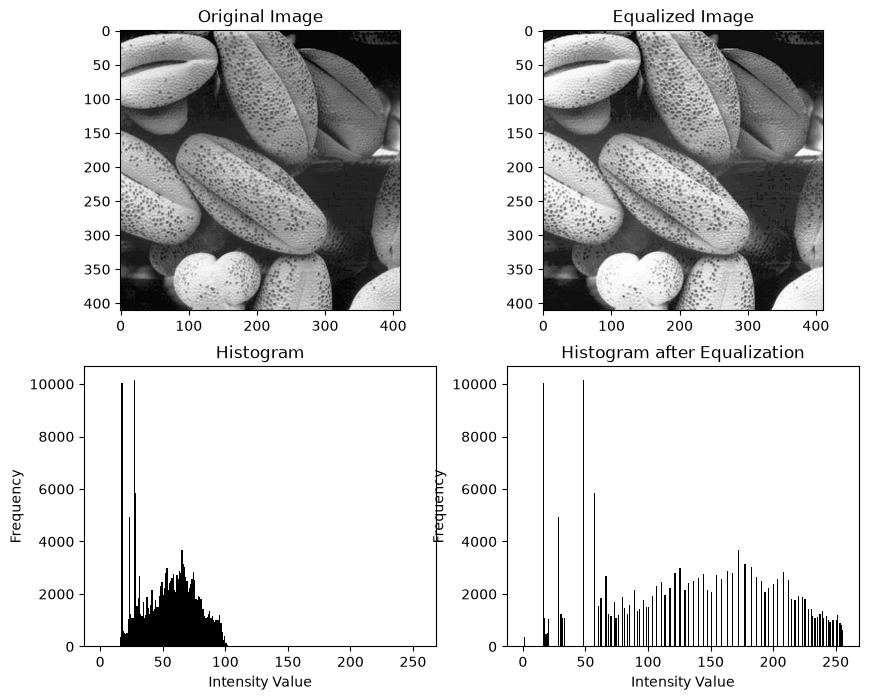

In [98]:
def histogram_equalization(image):
    histogram=np.zeros(256,dtype=np.int32) # Since there are intensity values from 0 to 255, we need an array of size 256
    for pixel in image.flatten():
        histogram[pixel] += 1  # Count the occurrences of each intensity value in the image

    # Now Calculate the cumulative distribution function (CDF) of the histogram
    cdf= np.cumsum(histogram)  

    #cdf_min= cdf[cdf > 0].min()  # Find the minimum non-zero value of the CDF
    num_pixels=image.size  # Total number of pixels in the image

    mapping = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        mapping[i] = round((cdf[i] / num_pixels) * 255) 

    equalized_image=mapping[image]  # Map the original pixel values to the new equalized values using the CDF
    return equalized_image

image5=cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question5.png',cv.IMREAD_GRAYSCALE)  # Read the image
equalized_image = histogram_equalization(image5)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Images
axes[0, 0].imshow(image5, cmap='gray')
axes[0, 0].set_title('Original Image')

axes[0, 1].imshow(equalized_image, cmap='gray')
axes[0, 1].set_title('Equalized Image')

# Histograms
axes[1, 0].hist(image5.ravel(), bins=256, range=[0, 256], color='black')
axes[1, 0].set_title('Histogram')
axes[1, 0].set_xlabel('Intensity Value')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(equalized_image.ravel(), bins=256, range=[0, 256], color='black')
axes[1, 1].set_title('Histogram after Equalization')
axes[1, 1].set_xlabel('Intensity Value')
axes[1, 1].set_ylabel('Frequency')




## Question 6

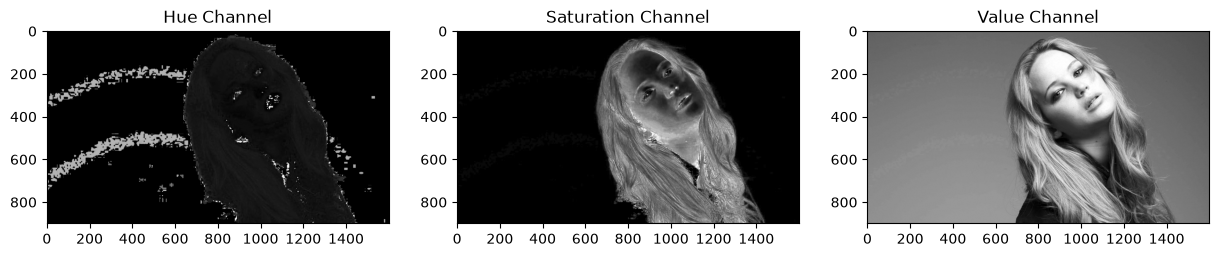

In [105]:
image6=cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question6.jpeg')  # Read the image in gray scale
hsv=cv.cvtColor(image6,cv.COLOR_BGR2HSV)  # Convert to HSV color space
H,S,V=cv.split(hsv)
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(H,cmap='gray')
plt.title('Hue Channel')

plt.subplot(1,3,2)
plt.imshow(S,cmap='gray')
plt.title('Saturation Channel')

plt.subplot(1,3,3)
plt.imshow(V,cmap='gray')   
plt.title('Value Channel')

plt.show()  # Show the plots



Will choose the Saturation Channel


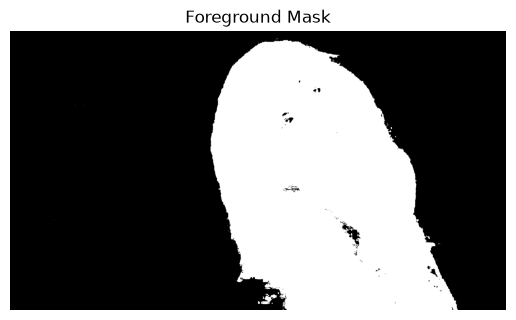

In [125]:
mask = cv.threshold(S,13,255,cv.THRESH_BINARY)[1]  # Create a binary mask where saturation is above 100
plt.imshow(mask, cmap='gray')
plt.title('Foreground Mask')
plt.axis('off')
plt.show()

In [ ]:
foreground = cv.bitwise_and(image6, image6, mask=mask)  # Apply the mask to the original image
#plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
# Since histogram equalization is normally performed on grayscale images
gray_foreground = cv.cvtColor(foreground, cv.COLOR_BGR2GRAY)  # Convert to grayscale
histogram = np.zeros(256, dtype=np.int32)  # Initialize histogram array
for pixel in gray_foreground.flatten():
    histogram[pixel] += 1  # Count the occurrences of each intensity value in the image      

# Here we should not calculate the black background
# In earlier equations cv.bitwise_and() makes the background black which is 0. So to get foreground pixels
foreground_pixels = gray_foreground[mask > 0]  # Get only the foreground pixels
# Now we create the histogram for the foreground pixels only
for pixels in foreground_pixels:
    histogram[pixels] += 1  # Count the occurrences of each intensity value in the foreground pixels


In [ ]:
cdf = np.cumsum(histogram)  # Calculate the cumulative distribution function (CDF) of the histogram 

In [ ]:
total_foreground_pixels = np.sum(histogram)  # Total number of foreground pixels    
mapping = np.zeros(256, dtype=np.uint8)

for i in range(256):
    mapping[i] = round((cdf[i] / total_foreground_pixels) * 255) 

equalized_foreground=mapping[gray_foreground]  # Map the original pixel values to the new equalized values using the CDF


In [ ]:
background = cv.bitwise_and(image6, image6, mask=cv.bitwise_not(mask))  # Get the background by inverting the mask
# Now we combine the equalized foreground with the original background
combined_image = cv.add(equalized_foreground, background)  # Combine the equalized foreground with the original background